# T3 Churn definition

## Approach

I define churn as an inactivity threshold: a player has "churned" once `N` days pass with no `bet` event. I test three thresholds: 14, 30 and 60 days.

I fit this with a Kaplan-Meier estimator (`lifelines`), which is the standard tool for "time until an event" data that includes **right-censored** observations, players who are still within their threshold window as of the last day of data. I do not know yet whether they will return or not. Treating them as "not churned" would be wrong, and dropping them would bias the curve toward players who churned early. Censoring handles this correctly.

Data source: `whizdomai-transactions`

Scope for this pass: only the two columns needed to build the labels (`partyId`, `dateTime`, aggregated to one row per player: first bet, last bet, bet count). No other player attributes yet, those come later, once the labels themselves are validated.

**Scope change: single brand, not all brands.** From here on this notebook, and every notebook downstream of it (`03_signal_explorer.ipynb`), is scoped to **`brandId = 64`** (`primus` only, `brandId` does not exist in `secundus`'s data, confirmed by checking a snapshot day before relying on it). Two reasons:

1. Grouping by brand is how this will eventually scale: each operator's landing data mixes several brands together (13 distinct `brandId` values under `primus`, 8-9 under `secundus`, no overlap between the two sets), and different brands are expected to behave differently. Building and validating the pipeline on one brand first, with `brandId` kept explicit everywhere rather than silently dropped, is what lets the same code run per-brand later without a rewrite.
2. It is faster downstream. Filtering to one `brandId` inside the SQL `WHERE` clause does **not** make the S3 file scan itself faster, DuckDB still has to open every small hourly file to check which rows match, that cost comes from file count, not row count (see `01_profiling.ipynb`). What it does make faster is everything after the scan: a smaller result set means a smaller pandas DataFrame, smaller cache files, and faster fits for the Kaplan-Meier, Cox, and lift computations downstream. I also get a real, separate speedup here specifically because `brandId = 64` only exists in `primus`, so I skip scanning `secundus` entirely, cutting the S3 file-opening cost roughly in half on its own.

**EUR conversion**: not needed in this notebook. The churn-definition labels here only use `partyId` and `dateTime` (bet timing), no money amounts, so there is nothing to convert. The project-wide EUR conversion (see `src/fx_rates.py`) applies from `03_signal_explorer.ipynb` onward, where monetary features (deposits, net loss, RTP) are built.

In [1]:
import datetime as dt
import os
from pathlib import Path

os.environ["AWS_PROFILE"] = "javier-whizdom-prod-ds"

import boto3
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter

BUCKET = "whizdomai-eu-central-1-650177547431-datalake-gmntc-prod"
LANDING_LEVEL = "org/10-landing/kafka-sink"
BET_TABLE = "whizdomai-transactions"

TARGET_BRAND_ID = 64
BRAND_OPERATORS = ["primus"]  # brandId=64 confirmed to exist only in primus (checked on a snapshot day)

HISTORY_START = dt.date(2026, 6, 18)
HISTORY_END = dt.date(2026, 9, 29)
HISTORY_DAYS = [HISTORY_START + dt.timedelta(days=i) for i in range((HISTORY_END - HISTORY_START).days + 1)]

CACHE_DIR = Path("../data/02_intermediate")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ACTIVITY_CACHE = CACHE_DIR / f"player_activity_span_brand{TARGET_BRAND_ID}.parquet"


def s3_duckdb():
    """DuckDB connection with the credentials of the SSO profile already loaded."""
    creds = boto3.Session(profile_name="javier-whizdom-prod-ds").get_credentials().get_frozen_credentials()
    con = duckdb.connect()
    con.sql("INSTALL httpfs; LOAD httpfs;")
    con.sql("SET memory_limit='16GB'")
    con.sql("SET threads=32")
    con.sql(f"""
        CREATE OR REPLACE SECRET s3_secret (
            TYPE S3, KEY_ID '{creds.access_key}', SECRET '{creds.secret_key}',
            SESSION_TOKEN '{creds.token}', REGION 'eu-central-1'
        );
    """)
    return con

## Data capture: first and last bet per player

One row per player: `first_bet`, `last_bet`, `n_bets`. This is a plain `GROUP BY` (`MIN`/`MAX`/`COUNT`), much cheaper per row.

Because of that, this only touches S3 once: if `player_activity_span.parquet` already exists under `../data/02_intermediate/`, we load it directly (instant).

In [2]:
def activity_span(operator, days, brand_id):
    """One row per player: first bet, last bet, bet count, for `operator` over `days`, one `brandId`."""
    paths = [
        f"s3://{BUCKET}/{LANDING_LEVEL}/{operator}/{BET_TABLE}/{d.year}/{d.month:02d}/{d.day:02d}/*.snappy.parquet"
        for d in days
    ]
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW bet_events AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    result = con.sql(f"""
        SELECT partyId,
               MIN(dateTime) AS first_bet,
               MAX(dateTime) AS last_bet,
               COUNT(*) AS n_bets
        FROM bet_events
        WHERE partyId IS NOT NULL AND dateTime IS NOT NULL AND brandId = {brand_id}
        GROUP BY partyId
    """).df()
    con.close()
    result.insert(0, "operator", operator)
    result.insert(1, "brandId", brand_id)
    return result


if ACTIVITY_CACHE.exists():
    activity = pd.read_parquet(ACTIVITY_CACHE)
    print(f"loaded from cache: {ACTIVITY_CACHE} ({len(activity):,} players)")
else:
    frames = [activity_span(operator, HISTORY_DAYS, TARGET_BRAND_ID) for operator in BRAND_OPERATORS]
    activity = pd.concat(frames, ignore_index=True)
    activity.to_parquet(ACTIVITY_CACHE)
    print(f"computed and cached to {ACTIVITY_CACHE} ({len(activity):,} players)")

activity.head()

loaded from cache: ../data/02_intermediate/player_activity_span_brand64.parquet (30,342 players)


,operator,brandId,partyId,first_bet,last_bet,n_bets
0,primus,64,8169907,2026-06-18 23:38:53.360000+02:00,2026-09-14 23:32:18.493000+02:00,5956
1,primus,64,4821182,2026-06-18 23:56:43.203000+02:00,2026-09-29 23:00:58.560000+02:00,203569
2,primus,64,16121426,2026-06-18 21:59:21.683000+02:00,2026-09-29 21:03:52.093000+02:00,65029
3,primus,64,12772953,2026-06-18 22:59:28.213000+02:00,2026-09-27 17:41:32.027000+02:00,12207
4,primus,64,13545448,2026-06-18 22:22:57.327000+02:00,2026-09-30 01:59:59.637000+02:00,208491


## Churn labels: duration and event/censored, per threshold

For each player:

- `duration_days = last_bet - first_bet` ,their observed tenure (time between their first and last bet in the data).
- `observation_end` = the last date I have data for (max `last_bet` across everyone).
- For a given threshold `N`: `event = 1` (churn confirmed) if `observation_end - last_bet >= N` days. I have actually observed `N` days of silence. Otherwise `event = 0` (**censored**): not enough time has passed since their last bet to know whether they will come back before hitting `N` days, so I do not know their true churn time yet.

Two limits worth being explicit about, not fixed here:

- **Left truncation.** Landing history starts `2026-06-18`. A player active before that date has their true first-ever bet unknown , `first_bet` here means "first bet observed in this window", not "first bet ever". This mostly affects tenure length for players who were already active when the window opens, not the churn/censoring label itself.
- **Short window vs. large thresholds.** With ~104 days of history, the 60-day threshold only has about 44 days of margin to confirm churn (`104 - 60`). Players whose first bet is recent have little chance to be confirmed either way at 60 days, expect a much higher censoring rate at 60 days than at 14.

In [3]:
THRESHOLDS_DAYS = [14, 30, 60]

observation_end = activity["last_bet"].max()

churn = activity.copy()
churn["duration_days"] = (churn["last_bet"] - churn["first_bet"]).dt.total_seconds() / 86400
churn["days_since_last_bet"] = (observation_end - churn["last_bet"]).dt.total_seconds() / 86400

for threshold in THRESHOLDS_DAYS:
    churn[f"event_{threshold}d"] = (churn["days_since_last_bet"] >= threshold).astype(int)

print(f"observation_end: {observation_end}")
print(f"players: {len(churn):,}")
for threshold in THRESHOLDS_DAYS:
    censored_pct = 100 * (1 - churn[f"event_{threshold}d"].mean())
    print(f"  {threshold:>2}d threshold: {censored_pct:.1f}% censored (still within their window)")

churn.head()

observation_end: 2026-09-30 01:59:59.883000+02:00
players: 30,342
  14d threshold: 36.6% censored (still within their window)
  30d threshold: 52.6% censored (still within their window)
  60d threshold: 75.8% censored (still within their window)


,operator,brandId,partyId,first_bet,last_bet,n_bets,duration_days,days_since_last_bet,event_14d,event_30d,event_60d
0,primus,64,8169907,2026-06-18 23:38:53.360000+02:00,2026-09-14 23:32:18.493000+02:00,5956,87.995430,15.102562,1,0,0
1,primus,64,4821182,2026-06-18 23:56:43.203000+02:00,2026-09-29 23:00:58.560000+02:00,203569,102.961289,0.124321,0,0,0
2,primus,64,16121426,2026-06-18 21:59:21.683000+02:00,2026-09-29 21:03:52.093000+02:00,65029,102.961463,0.205646,0,0,0
3,primus,64,12772953,2026-06-18 22:59:28.213000+02:00,2026-09-27 17:41:32.027000+02:00,12207,100.779211,2.346156,0,0,0
4,primus,64,13545448,2026-06-18 22:22:57.327000+02:00,2026-09-30 01:59:59.637000+02:00,208491,103.150721,0.000003,0,0,0


**Result.** `brandId=64` (`primus`), `observation_end = 2026-09-30 01:59:59+02:00` (same timezone spillover documented in `01_profiling.ipynb`). 30,342 players, far fewer than the all-brands population (385,328), as expected for a single brand out of 13 under `primus` alone. Censoring is noticeably higher than the all-brands numbers at every threshold:

| Threshold | Censored (brandId=64) | Confirmed churns | Censored (all brands, for reference) |
|---|---|---|---|
| 14d | 36.6% | 19,228 | 29.2% |
| 30d | 52.6% | 14,391 | 42.9% |
| 60d | 75.8% | 7,328 | 64.4% |

At 60 days, three-quarters of this brand's players are still censored. This brand's players take longer to confirm as churned than the all-brands average, consistent with the much higher median survival times found below.

## Fit Kaplan-Meier per threshold

Same `duration_days` for all three curves, only the `event` column changes per threshold (whether I can confirm the churn given each definition of "quiet long enough"). Comparing the three curves shows how sensitive the churn picture is to the choice of threshold.

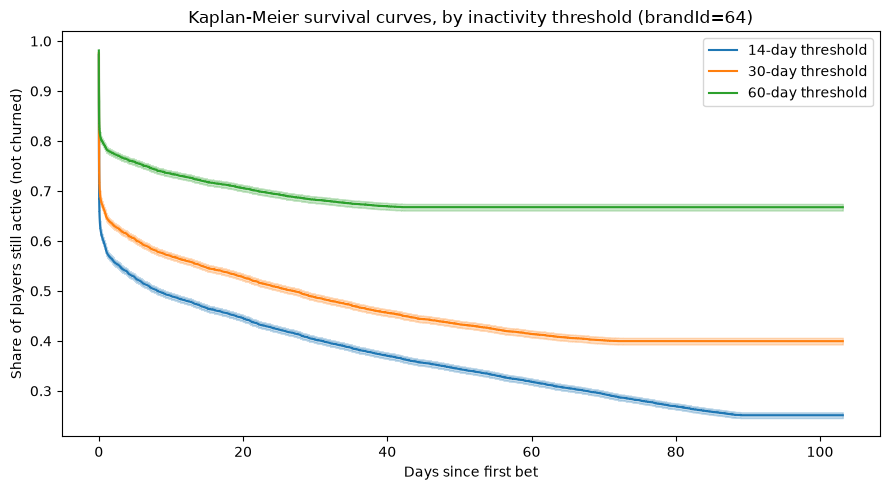

14d threshold: median survival = 8.1 days
30d threshold: median survival = 27.0 days
60d threshold: median survival = not reached (median survival > observed range)


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
fitters = {}

for threshold in THRESHOLDS_DAYS:
    kmf = KaplanMeierFitter(label=f"{threshold}-day threshold")
    kmf.fit(
        durations=churn["duration_days"],
        event_observed=churn[f"event_{threshold}d"],
    )
    fitters[threshold] = kmf
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("Days since first bet")
ax.set_ylabel("Share of players still active (not churned)")
ax.set_title(f"Kaplan-Meier survival curves, by inactivity threshold (brandId={TARGET_BRAND_ID})")
plt.tight_layout()
plt.savefig(f"../data/03_output/survival_curves_brand{TARGET_BRAND_ID}.png", dpi=300)
plt.show()

for threshold, kmf in fitters.items():
    median = kmf.median_survival_time_
    median_str = f"{median:.1f} days" if np.isfinite(median) else "not reached (median survival > observed range)"
    print(f"{threshold:>2}d threshold: median survival = {median_str}")

**Result.** Median survival for `brandId=64` is much longer than the all-brands figures from the original (all-brand) pass of this notebook:

| Threshold | Median survival (brandId=64) | Median survival (all brands, for reference) |
|---|---|---|
| 14d | 8.1 days | 0.8 days |
| 30d | 27.0 days | 3.9 days |
| 60d | not reached | not reached |

The all-brands medians were pulled down close to zero by one-time players dominating the pooled population (see `churn_definition_v0.md`, same caveat applies here in principle, not re-checked for this brand specifically in this pass). `brandId=64`'s players clearly behave differently: a typical player here is still active 8 days after their first bet under the 14-day definition, instead of churning almost immediately. This is itself evidence for the brand-grouping rationale in the Approach section above, pooling all brands together was hiding this.

## Return rate after dormancy

For each threshold `N`: of all the times a player went quiet for at least `N` days, what share of those dormancy episodes were eventually followed by a bet (a return), versus never followed by one?

This is a different question from the censoring rate above. Censoring only looks at each player's *final* gap (since their last bet up to the data cutoff). This looks at *every* gap of at least `N` days in a player's full history, not just the final one,a player can go dormant and return more than once.

Method: reduce `bet` to one row per (player, calendar day with at least one bet), `SELECT DISTINCT partyId, CAST(dateTime AS DATE)`. Then, per player, `LEAD()` gives the next active day; the gap between two consecutive active days is a dormancy episode if it is at least `N` days. If a next active day exists, that dormancy episode was followed by a return, by construction. The one gap per player with no next active day (`days since observation_end >= N`) is dormancy with no return observed yet, the same population as `event_Nd = 1` above, now expressed as a rate rather than a share of censoring.

`return_rate(N) = n_returns / (n_returns + n_still_dormant_no_return)`

Same cost profile as the data-capture step: full history, one scan per operator (day-level, not raw-event-level, but the S3 file count is what dominates either way), run once in the background, cached the same way.

In [5]:
GAPS_CACHE = CACHE_DIR / f"active_day_gaps_brand{TARGET_BRAND_ID}.parquet"


def active_day_gaps(operator, days, brand_id):
    """One row per (player, active day): the next active day, and the rank
    counting back from that player's last active day (1 = last)."""
    paths = [
        f"s3://{BUCKET}/{LANDING_LEVEL}/{operator}/{BET_TABLE}/{d.year}/{d.month:02d}/{d.day:02d}/*.snappy.parquet"
        for d in days
    ]
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW bet_events AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    result = con.sql(f"""
        WITH active_days AS (
            SELECT DISTINCT partyId, CAST(dateTime AS DATE) AS activity_date
            FROM bet_events
            WHERE partyId IS NOT NULL AND dateTime IS NOT NULL AND brandId = {brand_id}
        )
        SELECT partyId, activity_date,
               LEAD(activity_date) OVER (PARTITION BY partyId ORDER BY activity_date) AS next_active_date,
               ROW_NUMBER() OVER (PARTITION BY partyId ORDER BY activity_date DESC) AS rn_from_end
        FROM active_days
    """).df()
    con.close()
    result.insert(0, "operator", operator)
    result.insert(1, "brandId", brand_id)
    return result


if GAPS_CACHE.exists():
    gaps = pd.read_parquet(GAPS_CACHE)
    print(f"loaded from cache: {GAPS_CACHE} ({len(gaps):,} player-day rows)")
else:
    frames = [active_day_gaps(operator, HISTORY_DAYS, TARGET_BRAND_ID) for operator in BRAND_OPERATORS]
    gaps = pd.concat(frames, ignore_index=True)
    gaps.to_parquet(GAPS_CACHE)
    print(f"computed and cached to {GAPS_CACHE} ({len(gaps):,} player-day rows)")

gaps["gap_to_next_days"] = (gaps["next_active_date"] - gaps["activity_date"]).dt.days
observation_end_date = gaps["activity_date"].max()

return_rows = []
last_day = gaps[gaps["rn_from_end"] == 1].copy()
last_day["days_since_last"] = (observation_end_date - last_day["activity_date"]).dt.days

for threshold in THRESHOLDS_DAYS:
    n_returns = int(((gaps["next_active_date"].notna()) & (gaps["gap_to_next_days"] >= threshold)).sum())
    n_still_dormant = int((last_day["days_since_last"] >= threshold).sum())
    return_rate = n_returns / (n_returns + n_still_dormant)
    return_rows.append({
        "threshold_days": threshold, "n_returns": n_returns,
        "n_still_dormant": n_still_dormant, "return_rate": return_rate,
    })

return_rate_summary = pd.DataFrame(return_rows)
return_rate_summary

loaded from cache: ../data/02_intermediate/active_day_gaps_brand64.parquet (238,929 player-day rows)


,threshold_days,n_returns,n_still_dormant,return_rate
0,14,11553,19615,0.370669
1,30,2700,14633,0.155772
2,60,464,7516,0.058145


**Result.** `brandId=64`: 37.1% (14d) -> 15.6% (30d) -> 5.8% (60d). Same declining shape as the all-brands numbers, but every rate here is higher than the corresponding all-brands figure (28.3% / 12.2% / 3.8%), consistent with this brand's players being generally stickier (see the median survival Result above).

This raw comparison is not fair across thresholds, though. A dormancy episode only counts as "still dormant" under threshold `N` if the player's last active day is at least `N` days before `observation_end`. With ~104 days of history: the 60-day number can only use players whose last activity was in roughly the first 44 days of the window, while the 14-day number can use almost the whole window (~90 days). The same limit applies to "returns", the gap plus the return day both have to fit inside the window. So each threshold is measured on a different slice of the timeline, and part of the drop above could come from comparing different groups of players (by *when* they went quiet), not just from different silence lengths.

**Fix**: use the same player group for all three thresholds, only players whose last active day leaves at least 60 days of room (the most restrictive threshold).

In [6]:
max_threshold = max(THRESHOLDS_DAYS)
common_cutoff = observation_end_date - pd.Timedelta(days=max_threshold)
print(f"common eligibility cutoff (last active day must be <= this): {common_cutoff}")

gaps_matched = gaps[gaps["activity_date"] <= common_cutoff]
last_day_matched = last_day[last_day["activity_date"] <= common_cutoff]

matched_rows = []
for threshold in THRESHOLDS_DAYS:
    n_returns = int(((gaps_matched["next_active_date"].notna()) & (gaps_matched["gap_to_next_days"] >= threshold)).sum())
    n_still_dormant = int((last_day_matched["days_since_last"] >= threshold).sum())
    return_rate = n_returns / (n_returns + n_still_dormant)
    matched_rows.append({
        "threshold_days": threshold, "n_returns": n_returns,
        "n_still_dormant": n_still_dormant, "return_rate": return_rate,
    })

return_rate_matched = pd.DataFrame(matched_rows)
return_rate_matched

common eligibility cutoff (last active day must be <= this): 2026-08-01 00:00:00


/tmp/ipykernel_365060/3749097657.py:2: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  common_cutoff = observation_end_date - pd.Timedelta(days=max_threshold)


,threshold_days,n_returns,n_still_dormant,return_rate
0,14,6851,7516,0.476857
1,30,2007,7516,0.210753
2,60,464,7516,0.058145


**Result.** `brandId=64`. Common cutoff: `2026-08-01` (same date as the all-brands pass, it only depends on `observation_end` and the 60-day threshold, not on which players are included).

| Threshold | Raw rate | Fair rate | Fair rate (all brands, for reference) |
|---|---|---|---|
| 14d | 37.1% | **47.7%** | 32.6% |
| 30d | 15.6% | **21.1%** | 14.8% |
| 60d | 5.8% | 5.8% | 3.8% |

Same pattern as the all-brands version: fixing the comparison makes the drop from 14 to 60 days look bigger, not smaller (47.7% -> 5.8% here, versus 37.1% -> 5.8% raw), so the fix is not flattering the result. 60 days stays at 5.8% either way, its own definition already required this same restricted group. This brand's fair return rate is higher than the all-brands figure at every threshold, most noticeably at 14 days (47.7% vs 32.6%, almost half of this brand's "14-day churned" players actually come back).